# Threshold, Clinical Utility, Subgroup, and Error Analysis

This notebook is the final decision-analysis step of the ICU mortality prediction workflow.

Reusable metric, threshold, subgroup, and plotting logic is imported from `src/`. The notebook itself focuses on:

- threshold trade-offs;
- sensitivity versus alert burden;
- top-risk clinical review capacity;
- false-positive and false-negative analysis;
- subgroup performance;
- high-risk patient review;
- export of tables, predictions, figures, and analysis metadata.

## Model used

The main analysis uses the **uncalibrated Random Forest** saved by Notebook 7.

Notebook 8 demonstrated that calibration can appear excellent on the very small validation cohort but fail to generalize to the untouched test cohort. For this reason, threshold and ranking analyses here use the underlying Random Forest probabilities.

## Important limitation

The MIMIC-IV demo cohort is extremely small and contains very few mortality events. Threshold, subgroup, and error-analysis findings are exploratory and should not be interpreted as stable clinical estimates.

## 1. Locate the project root and import `src`

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()

if (cwd / "src").exists():
    PROJECT_DIR = cwd
elif (cwd.parent / "src").exists():
    PROJECT_DIR = cwd.parent
else:
    raise FileNotFoundError(
        "Could not locate the project root containing src/. "
        "Open this notebook from the clinical-outcome-prediction project."
    )

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

print("Project root:", PROJECT_DIR)
print("Python:", sys.executable)

Project root: C:\Projects\clinical-outcome-prediction
Python: c:\Projects\clinical-outcome-prediction\.venv\Scripts\python.exe


## 2. Imports and output paths

In [2]:
import json
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import (
    MODELS_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    PREDICTIONS_DIR,
    ANALYSIS_DIR,
)
from src.data import (
    load_modeling_splits,
    load_feature_config,
    validate_patient_split,
    validate_probability_vector,
)
from src.evaluation import (
    classification_metrics,
    evaluate_thresholds,
    review_capacity_analysis,
    subgroup_analysis,
    plot_confusion_matrix,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 300)

RANDOM_FOREST_PATH = MODELS_DIR / "random_forest.joblib"

DEFAULT_THRESHOLD = 0.50

CANDIDATE_THRESHOLDS = [
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.40,
    0.50,
    0.60,
]

REVIEW_CAPACITIES = [
    0.05,
    0.10,
    0.20,
    0.30,
    0.50,
]

for directory in [
    TABLES_DIR,
    FIGURES_DIR,
    PREDICTIONS_DIR,
    ANALYSIS_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

## 3. Load and validate data

In [3]:
train_df, validation_df, test_df = load_modeling_splits()

validate_patient_split(
    train_df,
    validation_df,
    test_df,
)

feature_config = load_feature_config()

target_column = feature_config["target_column"]
feature_columns = feature_config["retained_feature_columns"]

if not RANDOM_FOREST_PATH.exists():
    raise FileNotFoundError(
        f"Random Forest model was not found: {RANDOM_FOREST_PATH}. "
        "Run Notebook 7 first."
    )

random_forest_model = joblib.load(
    RANDOM_FOREST_PATH
)

X_test = test_df[
    feature_columns
].copy()

y_test = test_df[
    target_column
].copy()

print("Test shape:", test_df.shape)
print("Test patients:", test_df["subject_id"].nunique())
print("Test mortality events:", int(y_test.sum()))
print("Observed mortality rate:", round(float(y_test.mean()), 4))

Test shape: (19, 73)
Test patients: 15
Test mortality events: 2
Observed mortality rate: 0.1053


## 4. Generate test probabilities and risk ranks

In [4]:
test_probability = (
    random_forest_model.predict_proba(
        X_test
    )[:, 1]
)

validate_probability_vector(
    test_probability,
    vector_name="Random Forest test probability",
)

prediction_frame = test_df[
    [
        "subject_id",
        "hadm_id",
        "stay_id",
        target_column,
    ]
].copy()

prediction_frame[
    "predicted_probability"
] = test_probability

prediction_frame[
    "risk_rank"
] = (
    prediction_frame[
        "predicted_probability"
    ]
    .rank(
        ascending=False,
        method="first",
    )
    .astype(int)
)

prediction_frame[
    "risk_percentile"
] = (
    1
    - (
        prediction_frame["risk_rank"] - 1
    )
    / len(prediction_frame)
)

overall_metrics = classification_metrics(
    y_test,
    test_probability,
    threshold=DEFAULT_THRESHOLD,
)

print("Test AUROC:", overall_metrics["auroc"])
print("Test AUPRC:", overall_metrics["auprc"])

prediction_frame.sort_values(
    "predicted_probability",
    ascending=False,
).head(10)

Test AUROC: 0.6764705882352942
Test AUPRC: 0.3333333333333333


,subject_id,hadm_id,stay_id,hospital_expire_flag,predicted_probability,risk_rank,risk_percentile
8,10015860,24698912,36734659,0,0.646572,1,1.000000
13,10037975,27617929,39061571,1,0.640730,2,0.947368
16,10021938,23112364,39492446,0,0.638274,3,0.894737
18,10014354,29600294,39864867,0,0.610363,4,0.842105
7,10014354,27487226,34600477,0,0.539424,5,0.789474
4,10021938,27154822,33083787,0,0.470024,6,0.736842
12,10020306,23052851,38540883,0,0.467775,7,0.684211
9,10014354,22741225,37200209,0,0.412656,8,0.631579
3,10015860,25085565,32496174,0,0.412632,9,0.578947
14,10035185,22580999,39084876,0,0.411877,10,0.526316


## 5. Threshold analysis using `src.evaluation`

In [5]:
threshold_results = evaluate_thresholds(
    y_test,
    test_probability,
    thresholds=CANDIDATE_THRESHOLDS,
)

threshold_results

,auroc,auprc,threshold,accuracy,precision_ppv,recall_sensitivity,specificity,negative_predictive_value,f1_score,true_negatives,false_positives,false_negatives,true_positives,patients_flagged,flagged_percentage
0,0.676471,0.333333,0.05,0.105263,0.105263,1.0,0.000000,NaN,0.190476,0,17,0,2,19,1.000000
1,0.676471,0.333333,0.10,0.105263,0.105263,1.0,0.000000,NaN,0.190476,0,17,0,2,19,1.000000
2,0.676471,0.333333,0.15,0.105263,0.105263,1.0,0.000000,NaN,0.190476,0,17,0,2,19,1.000000
3,0.676471,0.333333,0.20,0.157895,0.111111,1.0,0.058824,1.000000,0.200000,1,16,0,2,18,0.947368
4,0.676471,0.333333,0.25,0.210526,0.117647,1.0,0.117647,1.000000,0.210526,2,15,0,2,17,0.894737
5,0.676471,0.333333,0.30,0.421053,0.153846,1.0,0.352941,1.000000,0.266667,6,11,0,2,13,0.684211
6,0.676471,0.333333,0.40,0.473684,0.100000,0.5,0.470588,0.888889,0.166667,8,9,1,1,10,0.526316
7,0.676471,0.333333,0.50,0.736842,0.200000,0.5,0.764706,0.928571,0.285714,13,4,1,1,5,0.263158
8,0.676471,0.333333,0.60,0.789474,0.250000,0.5,0.823529,0.933333,0.333333,14,3,1,1,4,0.210526


## 6. Identify useful exploratory operating points

In [6]:
best_f1_row = (
    threshold_results
    .sort_values(
        [
            "f1_score",
            "recall_sensitivity",
            "specificity",
        ],
        ascending=False,
    )
    .iloc[0]
)

high_sensitivity_candidates = (
    threshold_results.loc[
        threshold_results[
            "recall_sensitivity"
        ] >= 0.80
    ]
)

if high_sensitivity_candidates.empty:
    high_sensitivity_row = None
else:
    high_sensitivity_row = (
        high_sensitivity_candidates
        .sort_values(
            [
                "specificity",
                "precision_ppv",
            ],
            ascending=False,
        )
        .iloc[0]
    )

print("Best F1 operating point:")
display(best_f1_row)

if high_sensitivity_row is not None:
    print("\nHighest-specificity threshold among sensitivity >= 0.80:")
    display(high_sensitivity_row)

Best F1 operating point:


auroc                         0.676471
auprc                         0.333333
threshold                     0.600000
accuracy                      0.789474
precision_ppv                 0.250000
recall_sensitivity            0.500000
specificity                   0.823529
negative_predictive_value     0.933333
f1_score                      0.333333
true_negatives               14.000000
false_positives               3.000000
false_negatives               1.000000
true_positives                1.000000
patients_flagged              4.000000
flagged_percentage            0.210526
Name: 8, dtype: float64


Highest-specificity threshold among sensitivity >= 0.80:


auroc                         0.676471
auprc                         0.333333
threshold                     0.300000
accuracy                      0.421053
precision_ppv                 0.153846
recall_sensitivity            1.000000
specificity                   0.352941
negative_predictive_value     1.000000
f1_score                      0.266667
true_negatives                6.000000
false_positives              11.000000
false_negatives               0.000000
true_positives                2.000000
patients_flagged             13.000000
flagged_percentage            0.684211
Name: 5, dtype: float64

## 7. Plot threshold trade-offs

A lower threshold generally catches more deaths but produces more false-positive alerts. A higher threshold reduces alert burden but can miss mortality events.

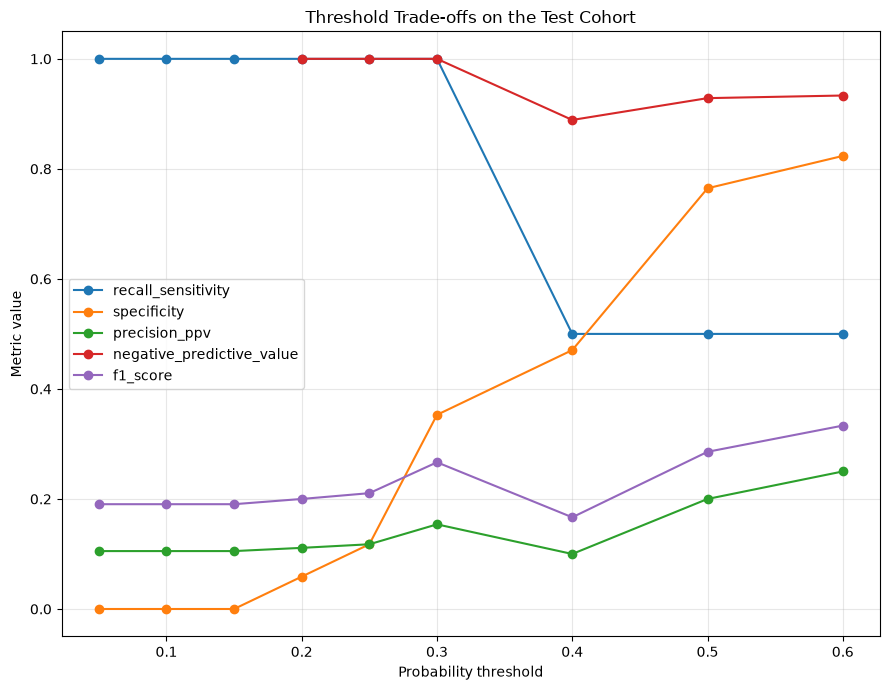

In [7]:
metric_columns = [
    "recall_sensitivity",
    "specificity",
    "precision_ppv",
    "negative_predictive_value",
    "f1_score",
]

fig, ax = plt.subplots(
    figsize=(9, 7)
)

for metric in metric_columns:
    ax.plot(
        threshold_results["threshold"],
        threshold_results[metric],
        marker="o",
        label=metric,
    )

ax.set_title(
    "Threshold Trade-offs on the Test Cohort"
)
ax.set_xlabel(
    "Probability threshold"
)
ax.set_ylabel(
    "Metric value"
)
ax.set_ylim(
    -0.05,
    1.05,
)
ax.grid(
    True,
    alpha=0.3,
)
ax.legend()

plt.tight_layout()

THRESHOLD_TRADEOFF_FIGURE = (
    FIGURES_DIR
    / "test_threshold_tradeoffs.png"
)

plt.savefig(
    THRESHOLD_TRADEOFF_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 8. Plot alert burden, false positives, and false negatives

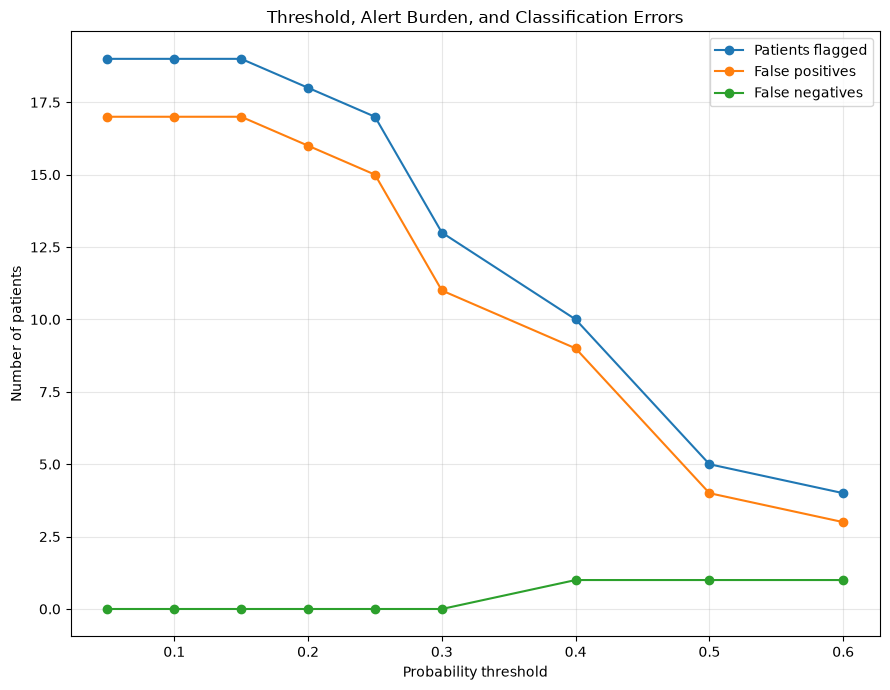

In [8]:
fig, ax = plt.subplots(
    figsize=(9, 7)
)

ax.plot(
    threshold_results["threshold"],
    threshold_results["patients_flagged"],
    marker="o",
    label="Patients flagged",
)

ax.plot(
    threshold_results["threshold"],
    threshold_results["false_positives"],
    marker="o",
    label="False positives",
)

ax.plot(
    threshold_results["threshold"],
    threshold_results["false_negatives"],
    marker="o",
    label="False negatives",
)

ax.set_title(
    "Threshold, Alert Burden, and Classification Errors"
)
ax.set_xlabel(
    "Probability threshold"
)
ax.set_ylabel(
    "Number of patients"
)
ax.grid(
    True,
    alpha=0.3,
)
ax.legend()

plt.tight_layout()

ALERT_BURDEN_FIGURE = (
    FIGURES_DIR
    / "test_threshold_alert_burden.png"
)

plt.savefig(
    ALERT_BURDEN_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 9. Clinical review-capacity analysis

A clinical team may not use a fixed probability threshold. Instead, it may review only the highest-risk patients because staffing capacity is limited.

This section asks:

> If clinicians review the top 5%, 10%, 20%, 30%, or 50% of patients by predicted risk, how many mortality events are captured?

In [9]:
capacity_results = (
    review_capacity_analysis(
        y_test,
        test_probability,
        capacities=REVIEW_CAPACITIES,
    )
)

capacity_results

,review_capacity_percentage,patients_reviewed,deaths_captured,total_deaths,death_capture_rate,precision_among_reviewed,false_alerts_among_reviewed
0,0.05,1,0,2,0.0,0.000000,1
1,0.10,2,1,2,0.5,0.500000,1
2,0.20,4,1,2,0.5,0.250000,3
3,0.30,6,1,2,0.5,0.166667,5
4,0.50,10,1,2,0.5,0.100000,9


## 10. Plot review capacity versus death capture

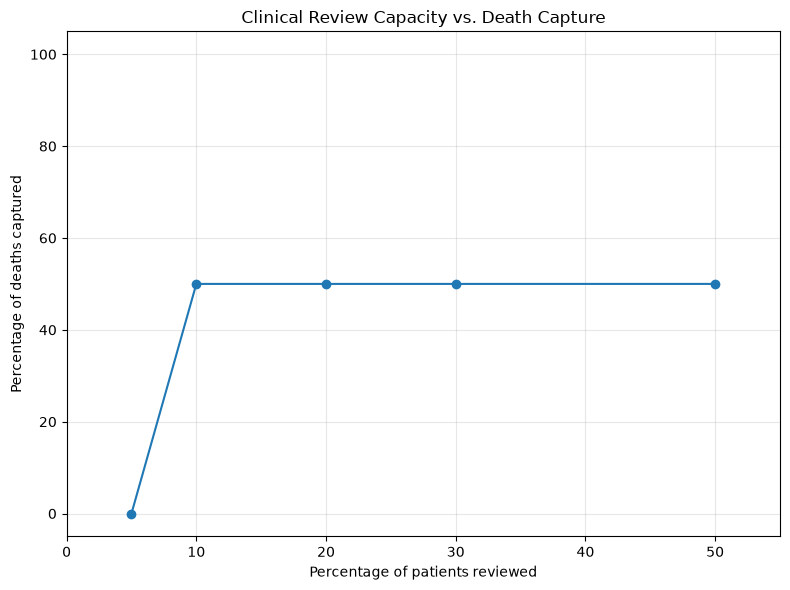

In [10]:
fig, ax = plt.subplots(
    figsize=(8, 6)
)

ax.plot(
    capacity_results[
        "review_capacity_percentage"
    ] * 100,
    capacity_results[
        "death_capture_rate"
    ] * 100,
    marker="o",
)

ax.set_title(
    "Clinical Review Capacity vs. Death Capture"
)
ax.set_xlabel(
    "Percentage of patients reviewed"
)
ax.set_ylabel(
    "Percentage of deaths captured"
)
ax.set_xlim(
    0,
    55,
)
ax.set_ylim(
    -5,
    105,
)
ax.grid(
    True,
    alpha=0.3,
)

plt.tight_layout()

CAPACITY_FIGURE = (
    FIGURES_DIR
    / "test_review_capacity_death_capture.png"
)

plt.savefig(
    CAPACITY_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 11. Create the high-risk patient review table

In [11]:
clinical_context_candidates = [
    "anchor_age",
    "gender",
    "first_careunit",
    "admission_type",
    "admission_location",
    "insurance",
    "race",
    "creatinine_first",
    "creatinine_min",
    "creatinine_max",
    "bun_first",
    "bun_min",
    "bun_max",
    "lactate_first",
    "lactate_max",
    "bicarbonate_first",
    "potassium_first",
    "map_min",
    "map_mean",
    "heart_rate_mean",
    "temperature_c_mean",
    "oxygen_saturation_mean",
]

available_context_columns = [
    column
    for column in clinical_context_candidates
    if column in test_df.columns
]

high_risk_review = (
    prediction_frame
    .merge(
        test_df[
            ["stay_id"]
            + available_context_columns
        ],
        on="stay_id",
        how="left",
    )
    .sort_values(
        "predicted_probability",
        ascending=False,
    )
)

high_risk_review.head(10)

,subject_id,hadm_id,stay_id,hospital_expire_flag,predicted_probability,risk_rank,risk_percentile,anchor_age,gender,first_careunit,admission_type,admission_location,insurance,race,creatinine_first,creatinine_min,creatinine_max,bun_first,bun_min,bun_max,lactate_first,lactate_max,bicarbonate_first,potassium_first,map_min,map_mean,heart_rate_mean,temperature_c_mean
8,10015860,24698912,36734659,0,0.646572,1,1.000000,53,M,Surgical Intensive Care Unit (SICU),EW EMER.,PHYSICIAN REFERRAL,Other,WHITE,8.1,8.1,8.3,76.0,76.0,78.0,0.9,0.9,9.0,4.4,66.0,83.230769,106.578947,36.736111
13,10037975,27617929,39061571,1,0.640730,2,0.947368,60,M,Medical Intensive Care Unit (MICU),URGENT,TRANSFER FROM HOSPITAL,Medicare,UNKNOWN,1.9,1.9,3.0,35.0,35.0,47.0,2.5,5.8,23.0,4.3,61.0,75.909091,131.500000,38.810317
16,10021938,23112364,39492446,0,0.638274,3,0.894737,65,M,Medical Intensive Care Unit (MICU),EW EMER.,EMERGENCY ROOM,Medicare,WHITE,15.2,10.3,15.2,108.0,63.0,108.0,NaN,NaN,18.0,6.3,82.0,97.650000,81.600000,36.722222
18,10014354,29600294,39864867,0,0.610363,4,0.842105,60,M,Medical/Surgical Intensive Care Unit (MICU/SICU),OBSERVATION ADMIT,PHYSICIAN REFERRAL,Other,WHITE,2.0,1.6,2.0,31.0,31.0,31.0,1.3,1.3,21.0,5.5,55.0,69.250000,97.600000,36.539683
7,10014354,27487226,34600477,0,0.539424,5,0.789474,60,M,Medical/Surgical Intensive Care Unit (MICU/SICU),URGENT,TRANSFER FROM HOSPITAL,Other,WHITE,1.9,1.5,1.9,41.0,31.0,41.0,NaN,NaN,20.0,5.9,81.0,92.043478,77.120000,36.888889
4,10021938,27154822,33083787,0,0.470024,6,0.736842,65,M,Medical Intensive Care Unit (MICU),EW EMER.,EMERGENCY ROOM,Medicare,WHITE,5.8,5.8,6.8,23.0,23.0,42.0,NaN,NaN,30.0,4.5,89.0,105.920000,79.280000,36.761905
12,10020306,23052851,38540883,0,0.467775,7,0.684211,74,F,Trauma SICU (TSICU),OBSERVATION ADMIT,PHYSICIAN REFERRAL,Other,BLACK/AFRICAN AMERICAN,2.2,2.0,2.2,29.0,29.0,30.0,3.4,3.4,21.0,4.4,66.0,77.280000,98.280000,36.317460
9,10014354,22741225,37200209,0,0.412656,8,0.631579,60,M,Surgical Intensive Care Unit (SICU),EW EMER.,EMERGENCY ROOM,Other,WHITE,1.1,1.1,1.1,13.0,13.0,13.0,NaN,NaN,23.0,5.0,52.0,82.800000,54.909091,36.644444
3,10015860,25085565,32496174,0,0.412632,9,0.578947,53,M,Medical Intensive Care Unit (MICU),EW EMER.,EMERGENCY ROOM,Other,WHITE,0.8,0.7,0.8,16.0,16.0,16.0,1.1,1.1,23.0,4.6,66.0,77.750000,102.529412,37.370370
14,10035185,22580999,39084876,0,0.411877,10,0.526316,70,M,Cardiac Vascular Intensive Care Unit (CVICU),URGENT,TRANSFER FROM HOSPITAL,Other,WHITE,1.2,1.2,1.3,21.0,20.0,21.0,1.8,2.2,24.0,4.9,62.0,75.178571,74.769231,36.451389


## 12. Classify true positives, false positives, false negatives, and true negatives

In [12]:
prediction_frame[
    "predicted_label"
] = (
    prediction_frame[
        "predicted_probability"
    ]
    >= DEFAULT_THRESHOLD
).astype(int)

prediction_frame[
    "prediction_category"
] = np.select(
    [
        (
            prediction_frame[target_column] == 1
        )
        & (
            prediction_frame["predicted_label"] == 1
        ),
        (
            prediction_frame[target_column] == 0
        )
        & (
            prediction_frame["predicted_label"] == 1
        ),
        (
            prediction_frame[target_column] == 1
        )
        & (
            prediction_frame["predicted_label"] == 0
        ),
        (
            prediction_frame[target_column] == 0
        )
        & (
            prediction_frame["predicted_label"] == 0
        ),
    ],
    [
        "true_positive",
        "false_positive",
        "false_negative",
        "true_negative",
    ],
    default="unknown",
)

prediction_frame[
    "prediction_category"
].value_counts()

prediction_category
true_negative     13
false_positive     4
false_negative     1
true_positive      1
Name: count, dtype: int64

## 13. False-negative analysis

In [13]:
false_negatives = (
    prediction_frame.loc[
        prediction_frame[
            "prediction_category"
        ] == "false_negative"
    ]
    .merge(
        test_df[
            ["stay_id"]
            + available_context_columns
        ],
        on="stay_id",
        how="left",
    )
    .sort_values(
        "predicted_probability"
    )
)

print(
    "False-negative count:",
    len(false_negatives),
)

false_negatives

False-negative count: 1


,subject_id,hadm_id,stay_id,hospital_expire_flag,predicted_probability,risk_rank,risk_percentile,predicted_label,prediction_category,anchor_age,gender,first_careunit,admission_type,admission_location,insurance,race,creatinine_first,creatinine_min,creatinine_max,bun_first,bun_min,bun_max,lactate_first,lactate_max,bicarbonate_first,potassium_first,map_min,map_mean,heart_rate_mean,temperature_c_mean
0,10035631,29276678,30932571,1,0.336582,12,0.421053,0,false_negative,63,M,Medical/Surgical Intensive Care Unit (MICU/SICU),OBSERVATION ADMIT,EMERGENCY ROOM,Other,WHITE,1.0,1.0,1.1,17.0,17.0,17.0,1.7,2.8,23.0,4.0,49.0,79.580645,121.387097,37.25


### Why false negatives matter

A false negative represents a patient who died but whose predicted probability remained below the operating threshold. In a screening-oriented workflow this is usually the most safety-relevant error type.

The goal of this analysis is **not** to claim that the model should have known the outcome. Instead, inspect whether missed cases:

- lacked strongly abnormal first-24-hour measurements;
- had substantial missingness;
- deteriorated after the prediction window;
- belonged to a subgroup with unstable model performance;
- received a probability close to the threshold.

## 14. False-positive analysis

In [14]:
false_positives = (
    prediction_frame.loc[
        prediction_frame[
            "prediction_category"
        ] == "false_positive"
    ]
    .merge(
        test_df[
            ["stay_id"]
            + available_context_columns
        ],
        on="stay_id",
        how="left",
    )
    .sort_values(
        "predicted_probability",
        ascending=False,
    )
)

print(
    "False-positive count:",
    len(false_positives),
)

false_positives.head(20)

False-positive count: 4


,subject_id,hadm_id,stay_id,hospital_expire_flag,predicted_probability,risk_rank,risk_percentile,predicted_label,prediction_category,anchor_age,gender,first_careunit,admission_type,admission_location,insurance,race,creatinine_first,creatinine_min,creatinine_max,bun_first,bun_min,bun_max,lactate_first,lactate_max,bicarbonate_first,potassium_first,map_min,map_mean,heart_rate_mean,temperature_c_mean
1,10015860,24698912,36734659,0,0.646572,1,1.000000,1,false_positive,53,M,Surgical Intensive Care Unit (SICU),EW EMER.,PHYSICIAN REFERRAL,Other,WHITE,8.1,8.1,8.3,76.0,76.0,78.0,0.9,0.9,9.0,4.4,66.0,83.230769,106.578947,36.736111
2,10021938,23112364,39492446,0,0.638274,3,0.894737,1,false_positive,65,M,Medical Intensive Care Unit (MICU),EW EMER.,EMERGENCY ROOM,Medicare,WHITE,15.2,10.3,15.2,108.0,63.0,108.0,NaN,NaN,18.0,6.3,82.0,97.650000,81.600000,36.722222
3,10014354,29600294,39864867,0,0.610363,4,0.842105,1,false_positive,60,M,Medical/Surgical Intensive Care Unit (MICU/SICU),OBSERVATION ADMIT,PHYSICIAN REFERRAL,Other,WHITE,2.0,1.6,2.0,31.0,31.0,31.0,1.3,1.3,21.0,5.5,55.0,69.250000,97.600000,36.539683
0,10014354,27487226,34600477,0,0.539424,5,0.789474,1,false_positive,60,M,Medical/Surgical Intensive Care Unit (MICU/SICU),URGENT,TRANSFER FROM HOSPITAL,Other,WHITE,1.9,1.5,1.9,41.0,31.0,41.0,NaN,NaN,20.0,5.9,81.0,92.043478,77.120000,36.888889


### Interpreting false positives

A high-risk survivor is not necessarily a meaningless prediction. The patient may have been severely ill and survived because of successful treatment, or the model may be responding to strong physiologic abnormalities that are associated with mortality risk but are not deterministic.

## 15. Compact prediction-category summary

In [15]:
error_category_summary = (
    prediction_frame
    .groupby(
        "prediction_category",
        as_index=False,
    )
    .agg(
        patients=(
            "stay_id",
            "count",
        ),
        mean_predicted_probability=(
            "predicted_probability",
            "mean",
        ),
        median_predicted_probability=(
            "predicted_probability",
            "median",
        ),
        minimum_predicted_probability=(
            "predicted_probability",
            "min",
        ),
        maximum_predicted_probability=(
            "predicted_probability",
            "max",
        ),
    )
)

error_category_summary

,prediction_category,patients,mean_predicted_probability,median_predicted_probability,minimum_predicted_probability,maximum_predicted_probability
0,false_negative,1,0.336582,0.336582,0.336582,0.336582
1,false_positive,4,0.608658,0.624318,0.539424,0.646572
2,true_negative,13,0.335733,0.302329,0.198354,0.470024
3,true_positive,1,0.640730,0.640730,0.640730,0.640730


## 16. Create subgroup variables

In [16]:
subgroup_frame = (
    prediction_frame
    .merge(
        test_df.drop(
            columns=[
                target_column
            ],
            errors="ignore",
        ),
        on=[
            "subject_id",
            "hadm_id",
            "stay_id",
        ],
        how="left",
    )
)

if "anchor_age" in subgroup_frame.columns:
    subgroup_frame[
        "age_group"
    ] = pd.cut(
        subgroup_frame[
            "anchor_age"
        ],
        bins=[
            -np.inf,
            49,
            69,
            np.inf,
        ],
        labels=[
            "18-49",
            "50-69",
            "70+",
        ],
    )

subgroup_candidates = [
    "gender",
    "age_group",
    "race",
    "insurance",
    "first_careunit",
    "admission_type",
]

available_subgroups = [
    column
    for column in subgroup_candidates
    if column in subgroup_frame.columns
]

print(
    "Available subgroup variables:",
    available_subgroups,
)

Available subgroup variables: ['gender', 'age_group', 'race', 'insurance', 'first_careunit', 'admission_type']


## 17. Run subgroup analysis using `src.evaluation.subgroup_analysis`

In [17]:
subgroup_tables = []

for subgroup_column in available_subgroups:
    subgroup_table = subgroup_analysis(
        subgroup_frame,
        subgroup_column=subgroup_column,
        target_column=target_column,
        probability_column="predicted_probability",
        threshold=DEFAULT_THRESHOLD,
        minimum_sample_size=20,
        minimum_events=5,
    )

    subgroup_tables.append(
        subgroup_table
    )

if subgroup_tables:
    subgroup_results = pd.concat(
        subgroup_tables,
        ignore_index=True,
    )
else:
    subgroup_results = pd.DataFrame()

subgroup_results

,subgroup_variable,subgroup_value,sample_size,deaths,event_rate,auroc,auprc,threshold,accuracy,precision_ppv,recall_sensitivity,specificity,negative_predictive_value,f1_score,true_negatives,false_positives,false_negatives,true_positives,patients_flagged,flagged_percentage,small_sample_warning,few_event_warning,interpretation_note
0,gender,F,4,0,0.000000,NaN,NaN,0.5,1.000000,0.0,0.0,1.000000,1.000000,0.000000,4,0,0,0,0,0.000000,True,True,Exploratory only: small sample or few events.
1,gender,M,15,2,0.133333,0.653846,0.350000,0.5,0.666667,0.2,0.5,0.692308,0.900000,0.285714,9,4,1,1,5,0.333333,True,True,Exploratory only: small sample or few events.
2,age_group,18-49,3,0,0.000000,NaN,NaN,0.5,1.000000,0.0,0.0,1.000000,1.000000,0.000000,3,0,0,0,0,0.000000,True,True,Exploratory only: small sample or few events.
3,age_group,50-69,12,2,0.166667,0.600000,0.361111,0.5,0.583333,0.2,0.5,0.600000,0.857143,0.285714,6,4,1,1,5,0.416667,True,True,Exploratory only: small sample or few events.
4,age_group,70+,4,0,0.000000,NaN,NaN,0.5,1.000000,0.0,0.0,1.000000,1.000000,0.000000,4,0,0,0,0,0.000000,True,True,Exploratory only: small sample or few events.
5,race,BLACK/AFRICAN AMERICAN,2,0,0.000000,NaN,NaN,0.5,1.000000,0.0,0.0,1.000000,1.000000,0.000000,2,0,0,0,0,0.000000,True,True,Exploratory only: small sample or few events.
6,race,HISPANIC OR LATINO,1,0,0.000000,NaN,NaN,0.5,1.000000,0.0,0.0,1.000000,1.000000,0.000000,1,0,0,0,0,0.000000,True,True,Exploratory only: small sample or few events.
7,race,HISPANIC/LATINO - SALVADORAN,1,0,0.000000,NaN,NaN,0.5,1.000000,0.0,0.0,1.000000,1.000000,0.000000,1,0,0,0,0,0.000000,True,True,Exploratory only: small sample or few events.
8,race,OTHER,1,0,0.000000,NaN,NaN,0.5,1.000000,0.0,0.0,1.000000,1.000000,0.000000,1,0,0,0,0,0.000000,True,True,Exploratory only: small sample or few events.
9,race,UNKNOWN,1,1,1.000000,NaN,1.000000,0.5,1.000000,1.0,1.0,NaN,NaN,1.000000,0,0,0,1,1,1.000000,True,True,Exploratory only: small sample or few events.


### Subgroup interpretation rule

Because the demo test set is tiny, subgroup results are **exploratory only**. A subgroup with a few patients or very few deaths cannot support strong claims about fairness, clinical validity, or comparative model performance.

## 18. Plot subgroup event rates

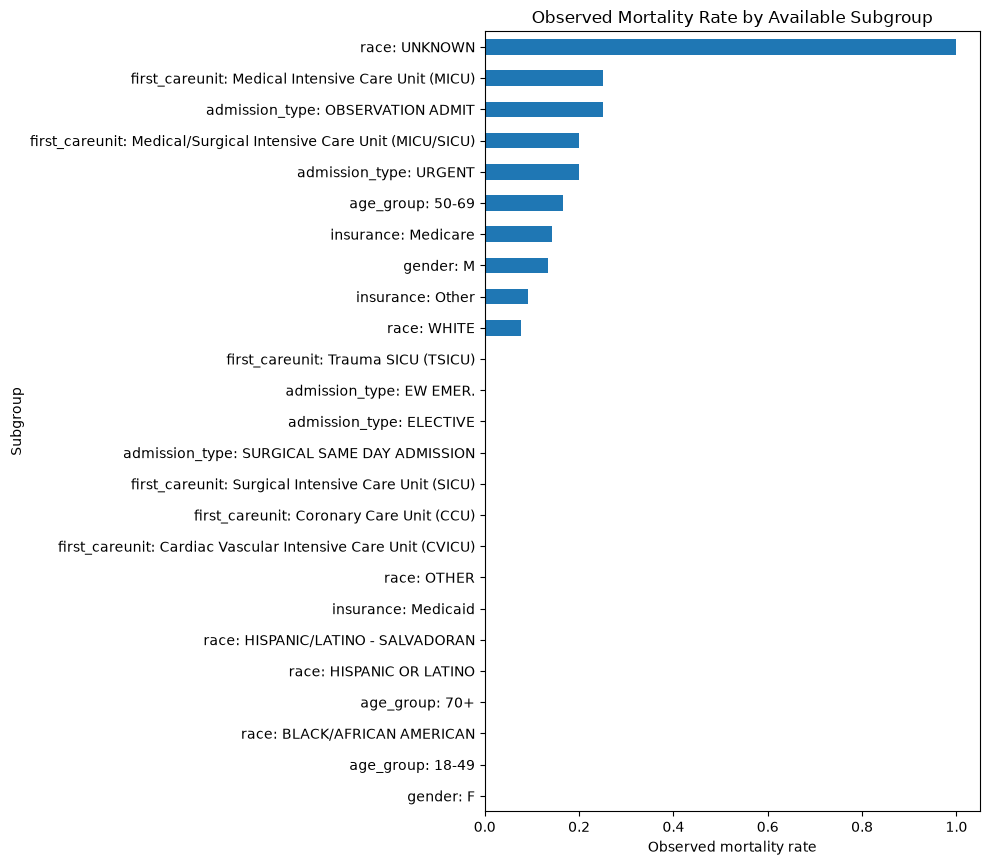

In [18]:
SUBGROUP_EVENT_RATE_FIGURE = (
    FIGURES_DIR
    / "test_subgroup_event_rates.png"
)

if subgroup_results.empty:
    print(
        "No subgroup variables were available."
    )
else:
    plot_data = subgroup_results.copy()

    plot_data[
        "label"
    ] = (
        plot_data[
            "subgroup_variable"
        ].astype(str)
        + ": "
        + plot_data[
            "subgroup_value"
        ].astype(str)
    )

    plot_data = (
        plot_data
        .sort_values(
            "event_rate"
        )
    )

    ax = plot_data.plot(
        x="label",
        y="event_rate",
        kind="barh",
        legend=False,
        figsize=(
            10,
            max(
                6,
                len(plot_data) * 0.35,
            ),
        ),
    )

    ax.set_title(
        "Observed Mortality Rate by Available Subgroup"
    )
    ax.set_xlabel(
        "Observed mortality rate"
    )
    ax.set_ylabel(
        "Subgroup"
    )

    plt.tight_layout()

    plt.savefig(
        SUBGROUP_EVENT_RATE_FIGURE,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

## 19. Confusion matrix at the default 0.50 threshold

<Axes: title={'center': 'Random Forest Test Confusion Matrix (threshold=0.50)'}, xlabel='Predicted label', ylabel='True label'>

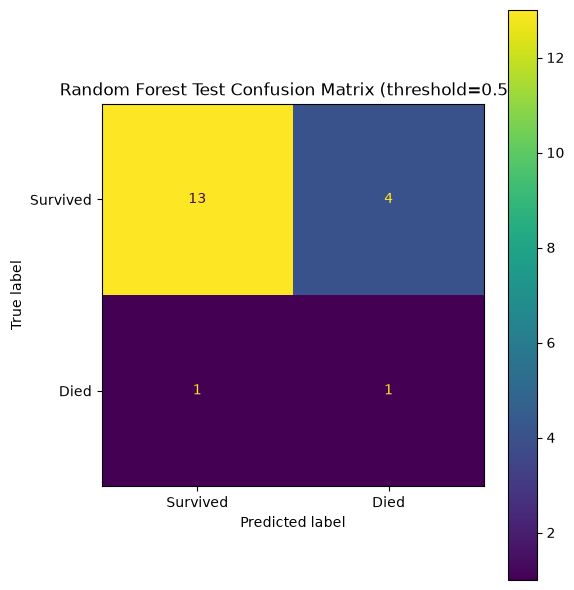

In [19]:
plot_confusion_matrix(
    y_test,
    test_probability,
    threshold=DEFAULT_THRESHOLD,
    title="Random Forest Test Confusion Matrix",
    save_path=(
        FIGURES_DIR
        / "random_forest_test_confusion_matrix_threshold_050.png"
    ),
)

## 20. Operational threshold summary

In [20]:
operational_threshold_summary = (
    threshold_results[
        [
            "threshold",
            "recall_sensitivity",
            "specificity",
            "precision_ppv",
            "negative_predictive_value",
            "f1_score",
            "patients_flagged",
            "flagged_percentage",
            "false_positives",
            "false_negatives",
            "true_positives",
            "true_negatives",
        ]
    ]
    .copy()
)

operational_threshold_summary[
    "interpretation"
] = np.select(
    [
        operational_threshold_summary[
            "threshold"
        ] <= 0.20,
        operational_threshold_summary[
            "threshold"
        ] <= 0.40,
    ],
    [
        "High-sensitivity / high-alert operating point",
        "Intermediate operating point",
    ],
    default="Lower-alert / higher-miss operating point",
)

operational_threshold_summary

,threshold,recall_sensitivity,specificity,precision_ppv,negative_predictive_value,f1_score,patients_flagged,flagged_percentage,false_positives,false_negatives,true_positives,true_negatives,interpretation
0,0.05,1.0,0.000000,0.105263,NaN,0.190476,19,1.000000,17,0,2,0,High-sensitivity / high-alert operating point
1,0.10,1.0,0.000000,0.105263,NaN,0.190476,19,1.000000,17,0,2,0,High-sensitivity / high-alert operating point
2,0.15,1.0,0.000000,0.105263,NaN,0.190476,19,1.000000,17,0,2,0,High-sensitivity / high-alert operating point
3,0.20,1.0,0.058824,0.111111,1.000000,0.200000,18,0.947368,16,0,2,1,High-sensitivity / high-alert operating point
4,0.25,1.0,0.117647,0.117647,1.000000,0.210526,17,0.894737,15,0,2,2,Intermediate operating point
5,0.30,1.0,0.352941,0.153846,1.000000,0.266667,13,0.684211,11,0,2,6,Intermediate operating point
6,0.40,0.5,0.470588,0.100000,0.888889,0.166667,10,0.526316,9,1,1,8,Intermediate operating point
7,0.50,0.5,0.764706,0.200000,0.928571,0.285714,5,0.263158,4,1,1,13,Lower-alert / higher-miss operating point
8,0.60,0.5,0.823529,0.250000,0.933333,0.333333,4,0.210526,3,1,1,14,Lower-alert / higher-miss operating point


## 21. Save Notebook 10 outputs

In [21]:
THRESHOLD_RESULTS_PATH = (
    TABLES_DIR
    / "test_threshold_analysis.csv"
)

CAPACITY_RESULTS_PATH = (
    TABLES_DIR
    / "test_review_capacity_analysis.csv"
)

HIGH_RISK_REVIEW_PATH = (
    TABLES_DIR
    / "test_high_risk_patient_review.csv"
)

ERROR_CATEGORY_SUMMARY_PATH = (
    TABLES_DIR
    / "test_error_category_summary.csv"
)

SUBGROUP_RESULTS_PATH = (
    TABLES_DIR
    / "test_subgroup_analysis.csv"
)

OPERATIONAL_THRESHOLD_PATH = (
    TABLES_DIR
    / "test_operational_threshold_summary.csv"
)

PREDICTION_OUTPUT_PATH = (
    PREDICTIONS_DIR
    / "test_predictions_threshold_analysis.csv"
)

FALSE_NEGATIVE_PATH = (
    ANALYSIS_DIR
    / "false_negative_cases.csv"
)

FALSE_POSITIVE_PATH = (
    ANALYSIS_DIR
    / "false_positive_cases.csv"
)

METADATA_PATH = (
    ANALYSIS_DIR
    / "notebook10_analysis_metadata.json"
)

threshold_results.to_csv(
    THRESHOLD_RESULTS_PATH,
    index=False,
)

capacity_results.to_csv(
    CAPACITY_RESULTS_PATH,
    index=False,
)

high_risk_review.to_csv(
    HIGH_RISK_REVIEW_PATH,
    index=False,
)

error_category_summary.to_csv(
    ERROR_CATEGORY_SUMMARY_PATH,
    index=False,
)

subgroup_results.to_csv(
    SUBGROUP_RESULTS_PATH,
    index=False,
)

operational_threshold_summary.to_csv(
    OPERATIONAL_THRESHOLD_PATH,
    index=False,
)

prediction_frame.to_csv(
    PREDICTION_OUTPUT_PATH,
    index=False,
)

false_negatives.to_csv(
    FALSE_NEGATIVE_PATH,
    index=False,
)

false_positives.to_csv(
    FALSE_POSITIVE_PATH,
    index=False,
)

metadata = {
    "model_used": "Uncalibrated Random Forest",
    "default_error_analysis_threshold": DEFAULT_THRESHOLD,
    "candidate_thresholds": CANDIDATE_THRESHOLDS,
    "review_capacities": REVIEW_CAPACITIES,
    "test_rows": int(
        len(test_df)
    ),
    "test_deaths": int(
        y_test.sum()
    ),
    "test_event_rate": float(
        y_test.mean()
    ),
    "test_auroc": float(
        overall_metrics["auroc"]
    ),
    "test_auprc": float(
        overall_metrics["auprc"]
    ),
    "best_f1_threshold": float(
        best_f1_row["threshold"]
    ),
    "available_subgroups": (
        available_subgroups
    ),
    "limitations": [
        "MIMIC-IV demo cohort",
        "Very small test set",
        "Very few mortality events",
        "Internal evaluation only",
        "Subgroup estimates are unstable",
        "No causal interpretation",
        "Not intended for clinical use",
    ],
}

with open(
    METADATA_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        metadata,
        file,
        indent=2,
    )

print("Notebook 10 outputs saved.")

Notebook 10 outputs saved.


## 22. Validate output files

In [22]:
expected_outputs = [
    THRESHOLD_RESULTS_PATH,
    CAPACITY_RESULTS_PATH,
    HIGH_RISK_REVIEW_PATH,
    ERROR_CATEGORY_SUMMARY_PATH,
    SUBGROUP_RESULTS_PATH,
    OPERATIONAL_THRESHOLD_PATH,
    PREDICTION_OUTPUT_PATH,
    FALSE_NEGATIVE_PATH,
    FALSE_POSITIVE_PATH,
    METADATA_PATH,
    THRESHOLD_TRADEOFF_FIGURE,
    ALERT_BURDEN_FIGURE,
    CAPACITY_FIGURE,
]

if not subgroup_results.empty:
    expected_outputs.append(
        SUBGROUP_EVENT_RATE_FIGURE
    )

for path in expected_outputs:
    print(
        "[OK]" if path.exists() else "[MISSING]",
        path,
    )

assert all(
    path.exists()
    for path in expected_outputs
)

print(
    "All expected Notebook 10 outputs were created."
)

[OK] C:\Projects\clinical-outcome-prediction\results\tables\test_threshold_analysis.csv
[OK] C:\Projects\clinical-outcome-prediction\results\tables\test_review_capacity_analysis.csv
[OK] C:\Projects\clinical-outcome-prediction\results\tables\test_high_risk_patient_review.csv
[OK] C:\Projects\clinical-outcome-prediction\results\tables\test_error_category_summary.csv
[OK] C:\Projects\clinical-outcome-prediction\results\tables\test_subgroup_analysis.csv
[OK] C:\Projects\clinical-outcome-prediction\results\tables\test_operational_threshold_summary.csv
[OK] C:\Projects\clinical-outcome-prediction\results\predictions\test_predictions_threshold_analysis.csv
[OK] C:\Projects\clinical-outcome-prediction\results\analysis\false_negative_cases.csv
[OK] C:\Projects\clinical-outcome-prediction\results\analysis\false_positive_cases.csv
[OK] C:\Projects\clinical-outcome-prediction\results\analysis\notebook10_analysis_metadata.json
[OK] C:\Projects\clinical-outcome-prediction\results\figures\test_thres

## 23. Final interpretation

### Threshold selection

There is no universally optimal probability threshold. Lower thresholds increase sensitivity and reduce missed mortality events, but increase false-positive alerts and clinical review burden. Higher thresholds reduce alert volume but can miss high-risk patients.

### Error analysis

False negatives deserve particular attention in mortality screening because they represent mortality events that were assigned probabilities below the operating threshold. False positives should not automatically be interpreted as clinically meaningless; some may represent seriously ill patients who survived.

### Subgroup analysis

Subgroup estimates are exploratory because the MIMIC-IV demo test cohort is extremely small. These results cannot establish model fairness or subgroup-specific clinical validity.

### Model interpretation

This notebook evaluates predictive behavior and operational trade-offs. It does not establish causality or demonstrate readiness for clinical deployment.

## Core predictive-modeling phase complete

With Notebook 10 completed, the next engineering tasks are:

1. run the test suite with `pytest`;
2. clean and document the repository;
3. add GitHub Actions;
4. write the final README;
5. then begin the RWE extensions: survival analysis, trial-style cohort construction, and propensity-score analysis.